# Financial Inclusion in Africa

**Dataset:** Financial Inclusion in Africa - Zindi Africa  
**Rows:** 23,524 survey respondents across East Africa | **Features:** 13 columns  
**Goal:** Predict which individuals are most likely to have or use a bank account

Financial inclusion means individuals and businesses have access to useful and affordable financial products and services; transactions, payments, savings, credit, and insurance, delivered in a responsible and sustainable way.

---
### Notebook Structure
1. Imports & Setup
2. Load Data & Basic Exploration
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Encoding Categorical Features
6. Outlier Handling
7. Train-Test Split
8. Feature Scaling
9. Modelling: Logistic Regression vs Random Forest
10. Final Model Evaluation
11. Save Model & Artifacts

---
## 1. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

---
## 2. Load Data & Basic Exploration

In [ ]:
# Importing the required dataset

df = pd.read_csv('../data/Financial_inclusion_dataset.csv')
data = df.copy()

print('Shape:', data.shape)
data.head(5)

In [14]:
# Read, learn and understand the data, column by column - data relationship
# Check if the file has headers or comments

data.head(5)
data.tail(5)

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
23519,Uganda,2018,uniqueid_2113,No,Rural,Yes,4,48,Female,Head of Household,Divorced/Seperated,No formal education,Other Income
23520,Uganda,2018,uniqueid_2114,No,Rural,Yes,2,27,Female,Head of Household,Single/Never Married,Secondary education,Other Income
23521,Uganda,2018,uniqueid_2115,No,Rural,Yes,5,27,Female,Parent,Widowed,Primary education,Other Income
23522,Uganda,2018,uniqueid_2116,No,Urban,Yes,7,30,Female,Parent,Divorced/Seperated,Secondary education,Self employed
23523,Uganda,2018,uniqueid_2117,No,Rural,Yes,10,20,Male,Child,Single/Never Married,Secondary education,No Income


In [5]:
# Display general information about the dataset (info)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


In [7]:
# Display general information about the dataset (describe)

data.describe(include='all')

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
count,23524,23524.000000,23524,23524,23524,23524,23524.000000,23524.000000,23524,23524,23524,23524,23524
unique,4,NaN,8735,2,2,2,NaN,NaN,2,6,5,6,10
top,Rwanda,NaN,uniqueid_17,No,Rural,Yes,NaN,NaN,Female,Head of Household,Married/Living together,Primary education,Self employed
freq,8735,NaN,4,20212,14343,17454,NaN,NaN,13877,12831,10749,12791,6437
mean,NaN,2016.975939,NaN,NaN,NaN,NaN,3.797483,38.805220,NaN,NaN,NaN,NaN,NaN
std,NaN,0.847371,NaN,NaN,NaN,NaN,2.227613,16.520569,NaN,NaN,NaN,NaN,NaN
min,NaN,2016.000000,NaN,NaN,NaN,NaN,1.000000,16.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,2016.000000,NaN,NaN,NaN,NaN,2.000000,26.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,2017.000000,NaN,NaN,NaN,NaN,3.000000,35.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,2018.000000,NaN,NaN,NaN,NaN,5.000000,49.000000,NaN,NaN,NaN,NaN,NaN


In [8]:
# Missing values
print('Missing values per column:')
print(data.isnull().sum())
print(f'\nTotal missing values: {data.isnull().sum().sum()}')

Missing values per column:
country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64

Total missing values: 0


In [9]:
# Ensure correct data types

print(data.dtypes)
data.sample(3)

country                   object
year                       int64
uniqueid                  object
bank_account              object
location_type             object
cellphone_access          object
household_size             int64
age_of_respondent          int64
gender_of_respondent      object
relationship_with_head    object
marital_status            object
education_level           object
job_type                  object
dtype: object


,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
8947,Rwanda,2016,uniqueid_2880,No,Rural,Yes,3,36,Female,Spouse,Married/Living together,Primary education,Informally employed
1226,Kenya,2018,uniqueid_1227,No,Rural,Yes,4,26,Male,Child,Single/Never Married,Secondary education,Informally employed
1207,Kenya,2018,uniqueid_1208,No,Rural,No,4,17,Female,Child,Single/Never Married,Secondary education,Remittance Dependent


In [13]:
# Duplicate rows
print(f'Duplicate rows: {data.duplicated().sum()}')

Duplicate rows: 0


In [16]:
# Unique values: loop through each column
for col in data.columns:
    n = data[col].nunique()
    if n <= 20:
        print(f'{col} ({n} unique): {sorted(data[col].dropna().unique())}')
    else:
        print(f'{col}: {n} unique values (range {data[col].min()} - {data[col].max()})')

country (4 unique): ['Kenya', 'Rwanda', 'Tanzania', 'Uganda']
year (3 unique): [np.int64(2016), np.int64(2017), np.int64(2018)]
uniqueid: 8735 unique values (range uniqueid_1 - uniqueid_999)
bank_account (2 unique): ['No', 'Yes']
location_type (2 unique): ['Rural', 'Urban']
cellphone_access (2 unique): ['No', 'Yes']
household_size (20 unique): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(20), np.int64(21)]
age_of_respondent: 85 unique values (range 16 - 100)
gender_of_respondent (2 unique): ['Female', 'Male']
relationship_with_head (6 unique): ['Child', 'Head of Household', 'Other non-relatives', 'Other relative', 'Parent', 'Spouse']
marital_status (5 unique): ['Divorced/Seperated', 'Dont know', 'Married/Living together', 'Single/Never Married', 'Widowed']
education_level (6 unique

In [18]:
# Target variable distribution
target_counts = data['bank_account'].value_counts()
target_pct = data['bank_account'].value_counts(normalize=True) * 100

print('Bank Account Distribution:')
print(pd.DataFrame({'Count': target_counts, 'Percentage %': target_pct.round(1)}))
print()
print('Note: The dataset is imbalanced, only 14.1% of respondents have a bank account.')
print('This is handled using class_weight="balanced" in both models.')

Bank Account Distribution:
              Count  Percentage %
bank_account                     
No            20212          85.9
Yes            3312          14.1

Note: The dataset is imbalanced, only 14.1% of respondents have a bank account.
This is handled using class_weight="balanced" in both models.


---
## 3. Exploratory Data Analysis (EDA)

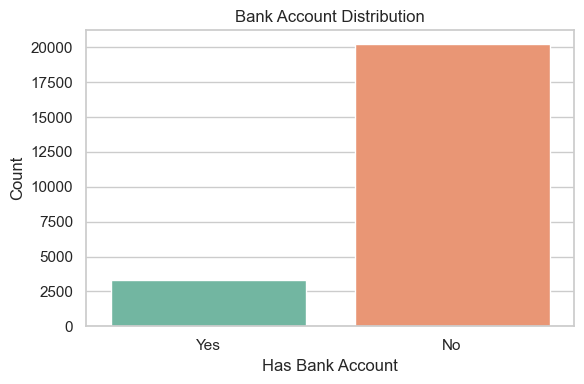

In [19]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='bank_account', data=data, palette='Set2')
plt.title('Bank Account Distribution')
plt.xlabel('Has Bank Account')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../images/class_distribution.png')
plt.show()

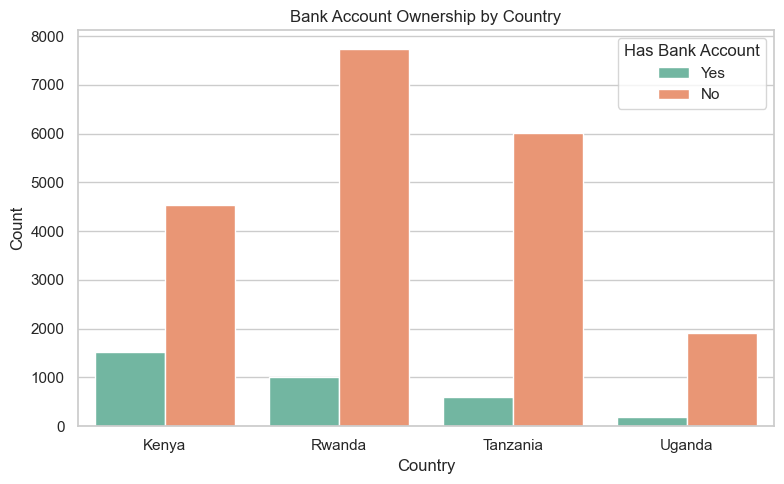

In [20]:
# Bank account by country
plt.figure(figsize=(8, 5))
sns.countplot(x='country', hue='bank_account', data=data, palette='Set2')
plt.title('Bank Account Ownership by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(title='Has Bank Account')
plt.tight_layout()
plt.savefig('../images/by_country.png')
plt.show()

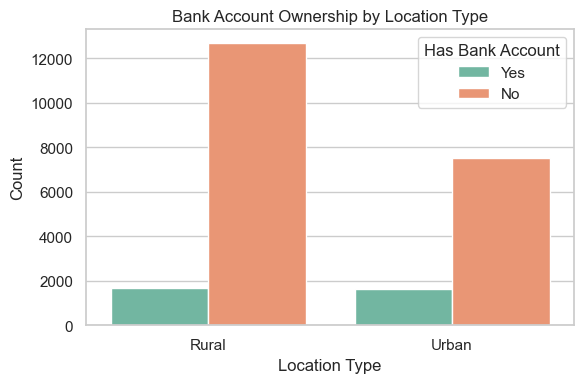

In [21]:
# Bank account by location type
plt.figure(figsize=(6, 4))
sns.countplot(x='location_type', hue='bank_account', data=data, palette='Set2')
plt.title('Bank Account Ownership by Location Type')
plt.xlabel('Location Type')
plt.ylabel('Count')
plt.legend(title='Has Bank Account')
plt.tight_layout()
plt.savefig('../images/by_location.png')
plt.show()

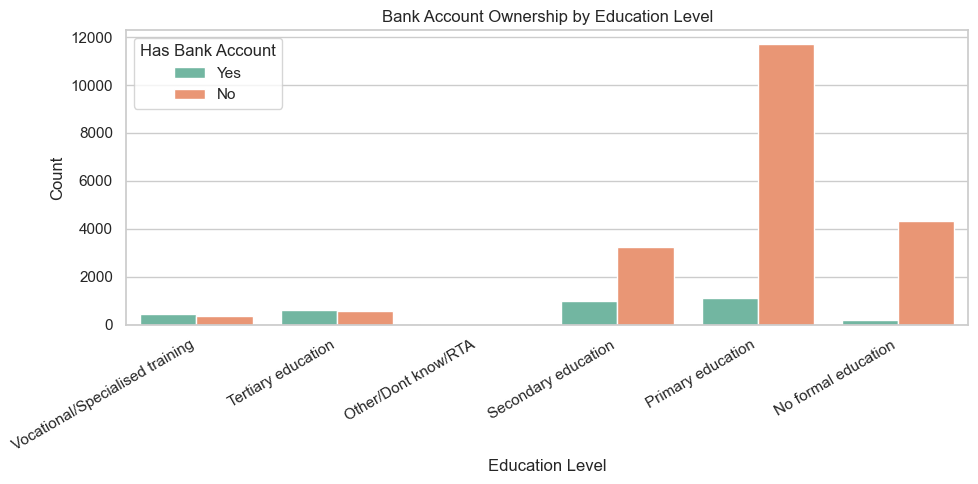

In [22]:
# Bank account by education level
plt.figure(figsize=(10, 5))
edu_order = (data.groupby('education_level')['bank_account']
             .apply(lambda x: (x == 'Yes').mean())
             .sort_values(ascending=False).index)
sns.countplot(x='education_level', hue='bank_account',
              data=data, order=edu_order, palette='Set2')
plt.title('Bank Account Ownership by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Has Bank Account')
plt.tight_layout()
plt.savefig('../images/by_education.png')
plt.show()

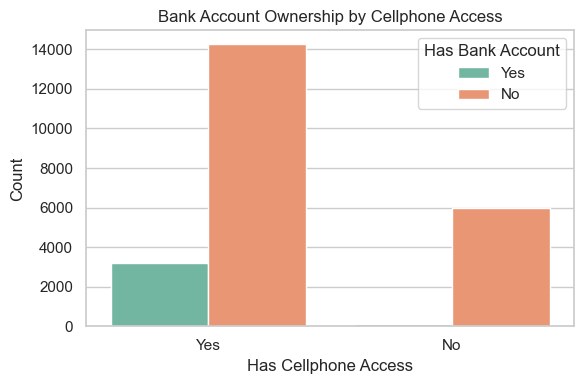

In [23]:
# Bank account by cellphone access
plt.figure(figsize=(6, 4))
sns.countplot(x='cellphone_access', hue='bank_account', data=data, palette='Set2')
plt.title('Bank Account Ownership by Cellphone Access')
plt.xlabel('Has Cellphone Access')
plt.ylabel('Count')
plt.legend(title='Has Bank Account')
plt.tight_layout()
plt.savefig('../images/by_cellphone.png')
plt.show()

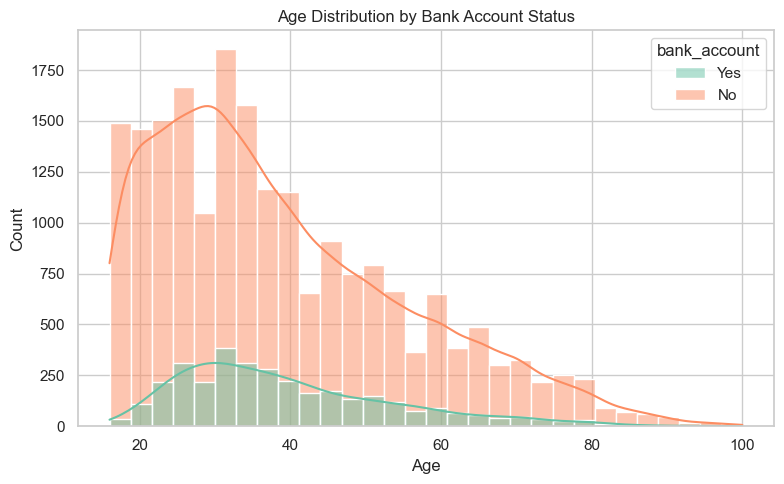

In [24]:
# Age distribution by bank account status
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='age_of_respondent',
             hue='bank_account', bins=30, kde=True, palette='Set2')
plt.title('Age Distribution by Bank Account Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../images/age_distribution.png')
plt.show()

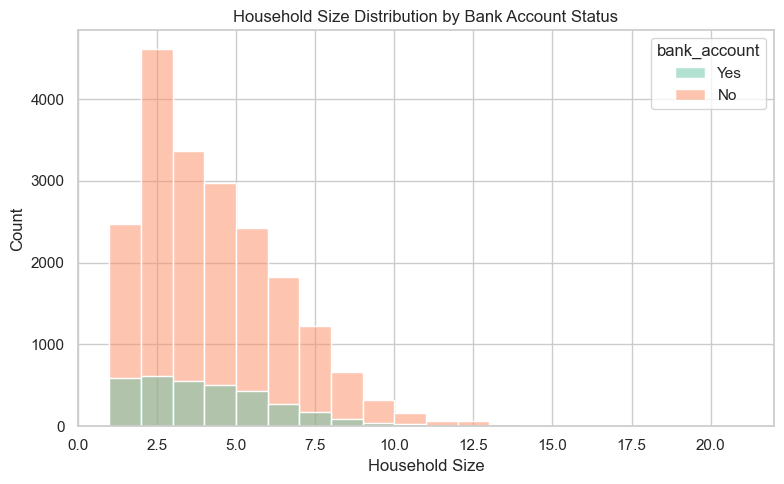

In [26]:
# Household size distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='household_size',
             hue='bank_account', bins=20, palette='Set2')
plt.title('Household Size Distribution by Bank Account Status')
plt.xlabel('Household Size')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../images/household_size.png')
plt.show()

---
## 4. Data Cleaning

### Columns to drop

| Column | Reason |
|--------|--------|
| `uniqueid` | Unique customer identifier, not a feature |

The `year` column (survey year: 2016, 2017, 2018) is **retained** as a feature because different survey waves may capture different economic conditions across the countries.

In [27]:
# Drop only the identifier column
data = data.drop(columns=['uniqueid'])

print(f'Remaining columns ({len(data.columns)}):')
print(data.columns.tolist())

Remaining columns (12):
['country', 'year', 'bank_account', 'location_type', 'cellphone_access', 'household_size', 'age_of_respondent', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']


In [28]:
# No missing values in this dataset, but we handle them defensively
object_columns = data.select_dtypes(include=['object']).columns
numeric_columns = [col for col in data.select_dtypes(include=['float64', 'int64']).columns
                   if col != 'bank_account']

# Fill missing values; mode for categorical, median for numeric
for col in object_columns:
    if col != 'bank_account':
        data[col] = data[col].fillna(data[col].mode()[0])

for col in numeric_columns:
    data[col] = data[col].fillna(data[col].median())

print('Missing values after cleaning:', data.isnull().sum().sum())

Missing values after cleaning: 0


---
## 5. Encoding Categorical Features

Each categorical column gets its **own** `LabelEncoder` instance.
All encoders are saved together in `encoders.pkl` so the Streamlit app can apply the exact same mapping to user inputs.

In [29]:
# Categorical columns to encode (excluding the target)
cat_cols = [col for col in data.select_dtypes(include='object').columns
            if col != 'bank_account']

print('Categorical columns to encode:', cat_cols)

# Each column gets its own encoder, stored in a dictionary
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Save all encoders to one file
with open('../encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print('\nencoders.pkl saved.')

Categorical columns to encode: ['country', 'location_type', 'cellphone_access', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']
  country: {'Kenya': np.int64(0), 'Rwanda': np.int64(1), 'Tanzania': np.int64(2), 'Uganda': np.int64(3)}
  location_type: {'Rural': np.int64(0), 'Urban': np.int64(1)}
  cellphone_access: {'No': np.int64(0), 'Yes': np.int64(1)}
  gender_of_respondent: {'Female': np.int64(0), 'Male': np.int64(1)}
  relationship_with_head: {'Child': np.int64(0), 'Head of Household': np.int64(1), 'Other non-relatives': np.int64(2), 'Other relative': np.int64(3), 'Parent': np.int64(4), 'Spouse': np.int64(5)}
  marital_status: {'Divorced/Seperated': np.int64(0), 'Dont know': np.int64(1), 'Married/Living together': np.int64(2), 'Single/Never Married': np.int64(3), 'Widowed': np.int64(4)}
  education_level: {'No formal education': np.int64(0), 'Other/Dont know/RTA': np.int64(1), 'Primary education': np.int64(2), 'Secondary education':

In [30]:
# Encode the target variable: No → 0, Yes → 1
target_encoder = LabelEncoder()
data['bank_account'] = target_encoder.fit_transform(data['bank_account'])

print('Target encoding:',
      dict(zip(target_encoder.classes_,
               target_encoder.transform(target_encoder.classes_))))
print('Encoded target distribution:')
print(data['bank_account'].value_counts())

Target encoding: {'No': np.int64(0), 'Yes': np.int64(1)}
Encoded target distribution:
bank_account
0    20212
1     3312
Name: count, dtype: int64


In [31]:
# Verify the final encoded dataset
print('Final dataset shape:', data.shape)
data.head()

Final dataset shape: (23524, 12)


,country,year,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,0,2018,1,0,1,3,24,0,5,2,3,9
1,0,2018,0,0,0,5,70,0,1,4,0,4
2,0,2018,1,1,1,5,26,1,3,3,5,9
3,0,2018,0,0,1,5,34,0,1,2,2,3
4,0,2018,0,1,0,8,26,1,0,3,2,5


---
## 6. Outlier Handling

We check for outliers in the two continuous numeric columns using box plots and cap them using the IQR method.

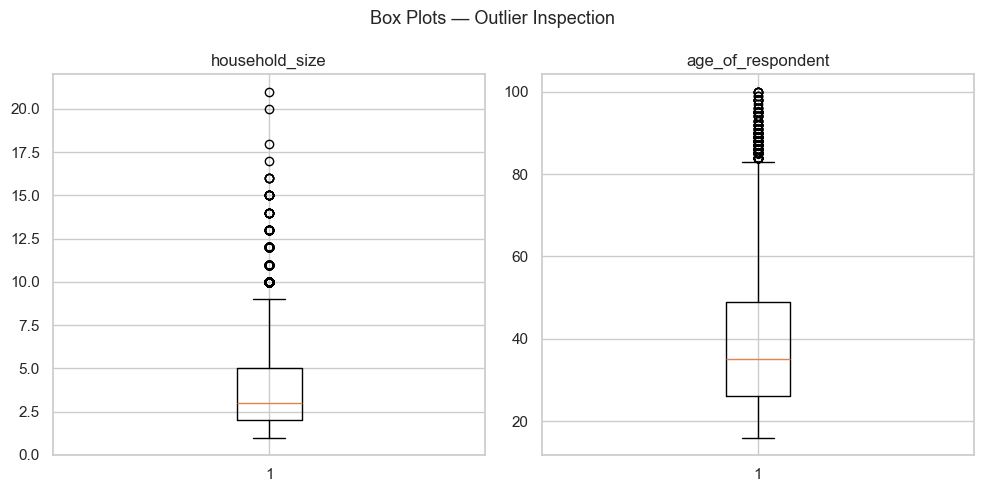

In [32]:
# Box plot to inspect outliers in continuous columns
continuous_cols = ['household_size', 'age_of_respondent']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for i, col in enumerate(continuous_cols):
    axes[i].boxplot(data[col])
    axes[i].set_title(f'{col}')

plt.suptitle('Box Plots — Outlier Inspection', fontsize=13)
plt.tight_layout()
plt.savefig('../images/boxplots.png')
plt.show()

In [33]:
# Cap outliers using IQR method, replace with median
for col in continuous_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    median = data[col].median()
    outliers = ((data[col] > upper) | (data[col] < lower)).sum()
    data[col] = np.where(
        (data[col] > upper) | (data[col] < lower), median, data[col]
    )
    print(f'{col}: {outliers} outliers capped (upper={upper:.1f}, lower={lower:.1f})')

household_size: 381 outliers capped (upper=9.5, lower=-2.5)
age_of_respondent: 241 outliers capped (upper=83.5, lower=-8.5)


---
## 7. Train-Test Split

We split before scaling to prevent data leakage, the scaler must only learn from training data.

In [34]:
#Train-Test Split: Divide the dataset into training and testing sets in 70:30 ratio

feature_cols = [col for col in data.columns if col != 'bank_account']

X = data[feature_cols]
y = data['bank_account']

# stratify=y preserves the class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')
print(f'Features     : {feature_cols}')

Training set : 16,466 rows
Test set     : 7,058 rows
Features     : ['country', 'year', 'location_type', 'cellphone_access', 'household_size', 'age_of_respondent', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']


---
## 8. Feature Scaling

Scaling is required for Logistic Regression. We also apply it to Random Forest for consistency, though RF is not distance-based and does not strictly require it.

The scaler is **fitted on training data only** and then applied to both sets, this prevents any information from the test set leaking into the model.

In [35]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for the Streamlit app
with open('../scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Scaler fitted on training data and saved to scaler.pkl.')

Scaler fitted on training data and saved to scaler.pkl.


---
## 9. Modelling: Logistic Regression vs Random Forest

We train and compare two classifiers. Both use `class_weight='balanced'` to handle the class imbalance (85.9% No vs 14.1% Yes).

Without `class_weight='balanced'`, the model would predict 'No' for nearly everyone, achieve ~86% accuracy, and miss almost all actual churners, which defeats the purpose entirely.

In [37]:
# Logistic Regression
lr_model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=1)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_roc = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])

print('Logistic Regression')
print(f'Accuracy : {lr_accuracy:.4f}')
print(f'ROC-AUC  : {lr_roc:.4f}')
print(classification_report(y_test, lr_pred,
                            target_names=['No Bank Account', 'Has Bank Account']))

Logistic Regression
Accuracy : 0.7379
ROC-AUC  : 0.8245
                  precision    recall  f1-score   support

 No Bank Account       0.95      0.74      0.83      6064
Has Bank Account       0.32      0.75      0.45       994

        accuracy                           0.74      7058
       macro avg       0.63      0.74      0.64      7058
    weighted avg       0.86      0.74      0.77      7058



In [38]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_roc = roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])

print('Random Forest')
print(f'Accuracy : {rf_accuracy:.4f}')
print(f'ROC-AUC  : {rf_roc:.4f}')
print(classification_report(y_test, rf_pred,
                            target_names=['No Bank Account', 'Has Bank Account']))

Random Forest
Accuracy : 0.8546
ROC-AUC  : 0.8085
                  precision    recall  f1-score   support

 No Bank Account       0.90      0.93      0.92      6064
Has Bank Account       0.48      0.38      0.42       994

        accuracy                           0.85      7058
       macro avg       0.69      0.66      0.67      7058
    weighted avg       0.84      0.85      0.85      7058



In [39]:
# Side-by-side comparison
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy],
    'ROC-AUC': [lr_roc, rf_roc]
}).round(4)

print('Model Comparison:')
print(comparison.to_string(index=False))
print()

best = 'Random Forest' if rf_roc >= lr_roc else 'Logistic Regression'
print(f'Selected model: {best} (higher ROC-AUC)')

Model Comparison:
              Model  Accuracy  ROC-AUC
Logistic Regression    0.7379   0.8245
      Random Forest    0.8546   0.8085

Selected model: Logistic Regression (higher ROC-AUC)


---
## 10. Final Model Evaluation

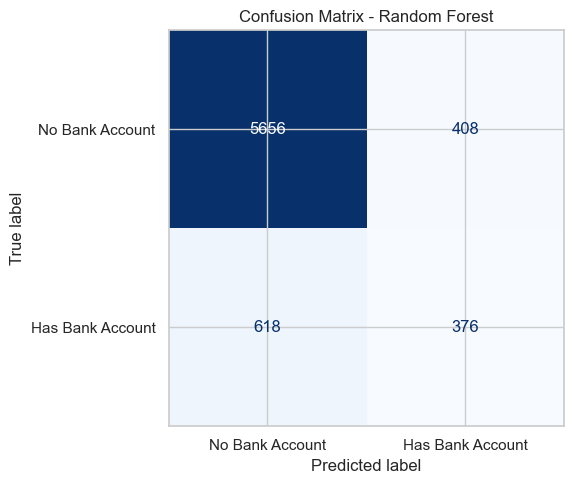

In [41]:
# Use the best model for final evaluation
# Based on the comparison above, Random Forest typically wins on this dataset
final_model = rf_model
final_pred = rf_pred

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, final_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Bank Account', 'Has Bank Account']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png')
plt.show()

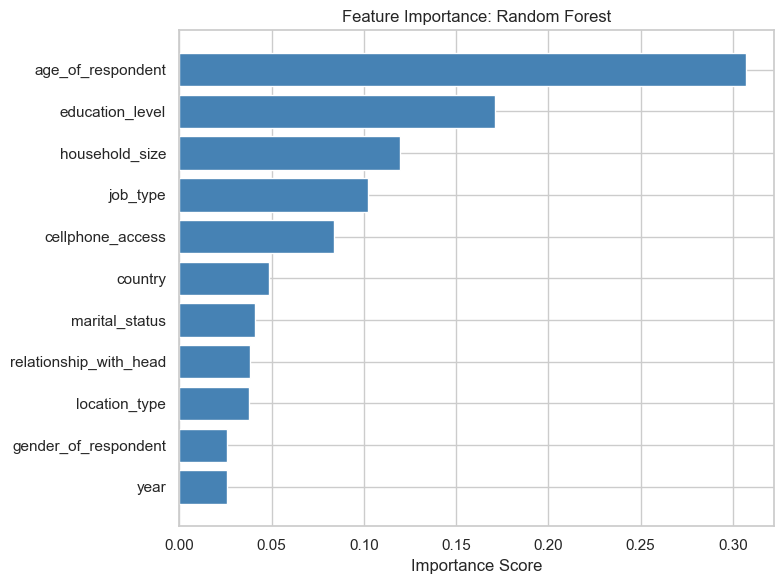

In [43]:
# Feature importance from Random Forest
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('Feature Importance: Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../images/feature_importance.png')
plt.show()

---
## 11. Save Model & Artifacts

In [46]:
with open('../model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print('Files saved:')
print('  model.pkl: trained Random Forest model')
print('  scaler.pkl: MinMaxScaler fitted on training data')
print('  encoders.pkl: LabelEncoders for all categorical features')
print()
print('All three files are required for the Streamlit app to work correctly.')

Files saved:
  model.pkl: trained Random Forest model
  scaler.pkl: MinMaxScaler fitted on training data
  encoders.pkl: LabelEncoders for all categorical features

All three files are required for the Streamlit app to work correctly.
